In [21]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import os
from autoenkoop import *
import scipy
import matplotlib.pyplot as plt
import pydmd

DEVICE = "cpu"

In [229]:
# system
x0 = 5
a = 0.9
def f(x0, a, t):
    return x0 * a**t

# sampling
t0 = 0
te = 100
dt = 1
t = np.linspace(t0, te, int((te-t0)/dt)+1)

# data generation
trajectory = f(x0, a, t)

# noise
noise_scale = 0.1
noise = np.random.normal(scale=noise_scale, size=trajectory.shape)
noised_trajectory = trajectory + noise

# nonlinear transformed data
affine_trajectory = trajectory+2

In [266]:
def visualize_trajectory_dynamics(data):
    Xt = data[:-1]
    Xtp1 = data[1:]
    _visualize_trajectory_dynamics(Xt, Xtp1)

def _visualize_trajectory_dynamics(Xt, Xtp1):
    K = np.expand_dims(Xtp1, 0) @ np.linalg.pinv(np.expand_dims(Xt,0))
    slope = K[0][0]
    print(slope)
    slope_x = np.array([np.min(Xt)-0.01, np.max(Xt)+0.01])
    slope_y = slope*slope_x
    fig, ax = plt.subplots()
    ax.plot(Xt, Xtp1, "x")
    ax.plot(slope_x, slope_y)
    ax.set(title="", xlabel=r"$x_t$", ylabel=r"$x_{t+1}$")
    plt.show()

0.8999999999999998


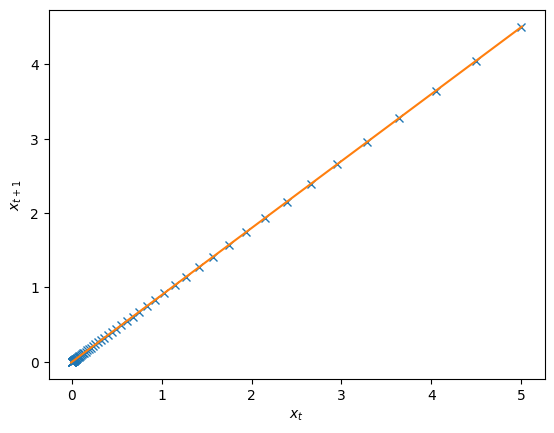

In [267]:
visualize_trajectory_dynamics(trajectory)

0.8897802838282884


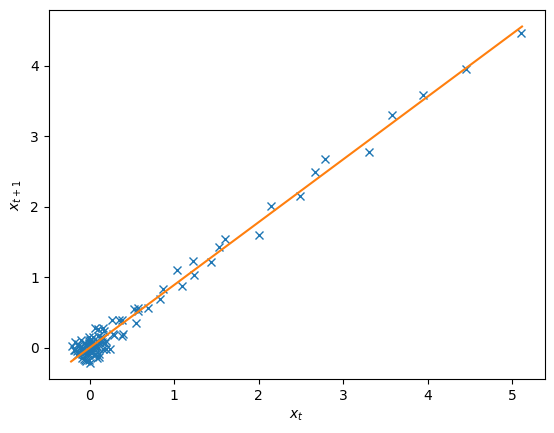

In [268]:
visualize_trajectory_dynamics(noised_trajectory)

0.9683454569631904


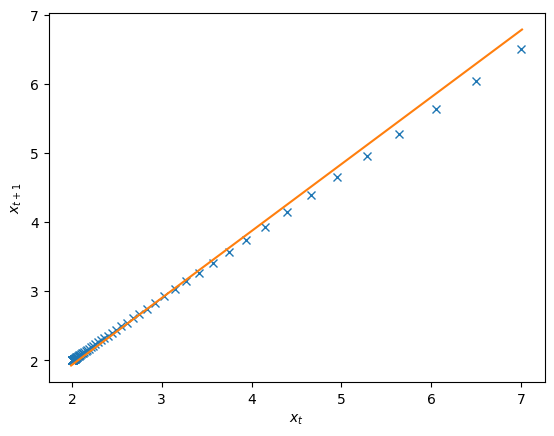

In [269]:
visualize_trajectory_dynamics(affine_trajectory)

In [ ]:
class TOffsetDataset(torch.utils.data.Dataset):
    def __init__(self, data, t_offset = 1):
        # data: numpy array of shape (t, x, z, v)
        self.X_0 = np.expand_dims(data[:-t_offset],1)
        self.X_t = np.expand_dims(data[t_offset:], 1)
       
    def __len__(self):
        return self.X_0.shape[0]

    def __getitem__(self, idx):
        return self.X_0[idx], self.X_t[idx]

In [306]:
class TestKAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = torch.nn.Linear(1, 1, bias=True, dtype=torch.float64)

        self.linear_dynamics = torch.nn.Linear(1, 1, bias=False, dtype=torch.float64)
        # Decoder
        self.decoder = torch.nn.Linear(1, 1, bias=True, dtype=torch.float64)

    def forward(self, x_t):
        z_t = self.encoder(x_t)
        z_t_plus_1 = self.linear_dynamics(z_t)
        x_t_plus_1 = self.decoder(z_t_plus_1)
        return x_t_plus_1

class ManualKAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = torch.nn.Linear(1, 1, bias=True, dtype=torch.float64)

        #self.linear_dynamics = torch.nn.Linear(1, 1, bias=False, dtype=torch.float64)
        # Decoder
        self.decoder = torch.nn.Linear(1, 1, bias=True, dtype=torch.float64)

    def forward(self, x_t):
        z_t = self.encoder(x_t)
        #z_t_plus_1 = self.linear_dynamics(z_t)
        x_t_plus_1 = self.decoder(z_t_plus_1)
        return x_t_plus_1

def visualize_pred_vs_real_dynamics(Xt, predXtp1, realXtp1, learned_slope):
    K = np.expand_dims(predXtp1, 0) @ np.linalg.pinv(np.expand_dims(Xt,0))
    slope = K[0][0]
    print(slope)
    slope_x = np.array([np.min(Xt)-0.01, np.max(Xt)+0.01])
    slope_y = slope*slope_x
    learned_slope_y = learned_slope*slope_x
    fig, ax = plt.subplots()
    ax.plot(Xt, predXtp1, "x")
    ax.plot(Xt, realXtp1, "o")
    ax.plot(slope_x, slope_y)
    ax.plot(slope_x, learned_slope_y)
    ax.set(title="", xlabel=r"$x_t$", ylabel=r"$x_{t+1}$")
    plt.show()

-0.3862914205466825


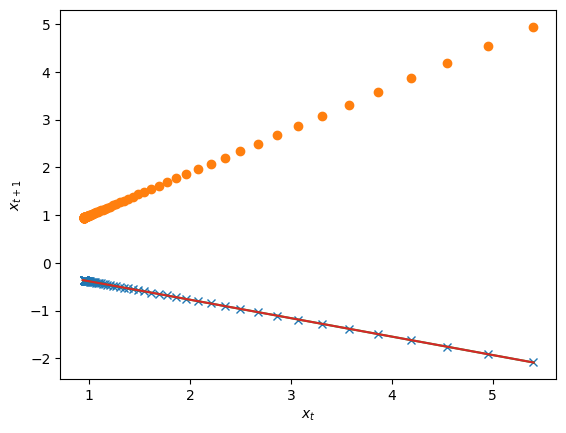

-0.35396957693959025


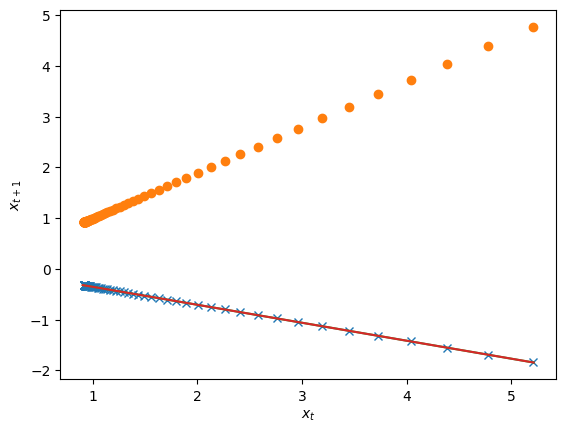

-0.31835456399020967


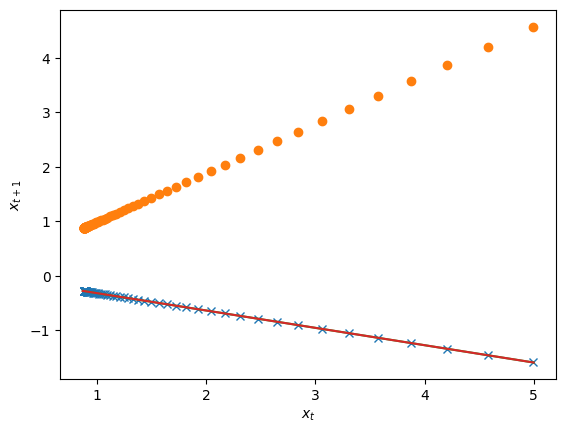

-0.281106538225666


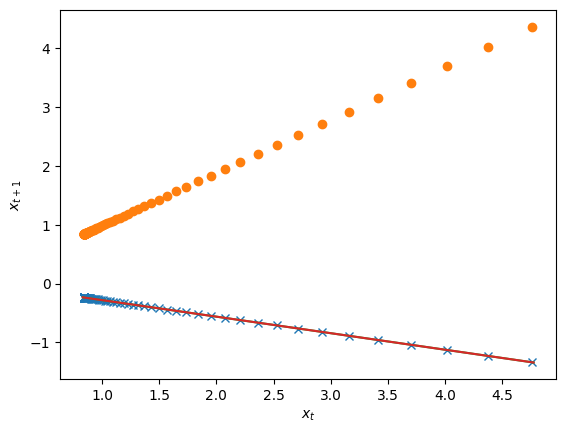

-0.2435314349947906


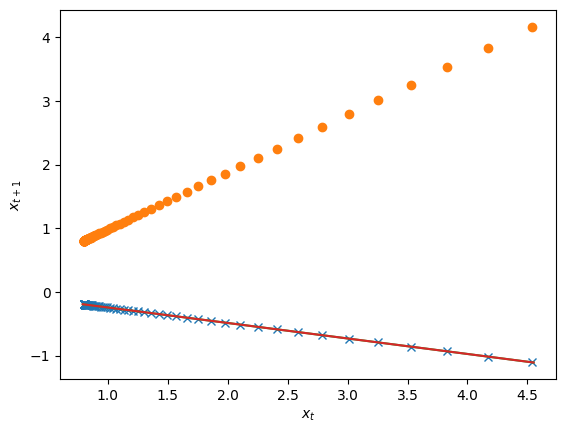

-0.20604504508316807


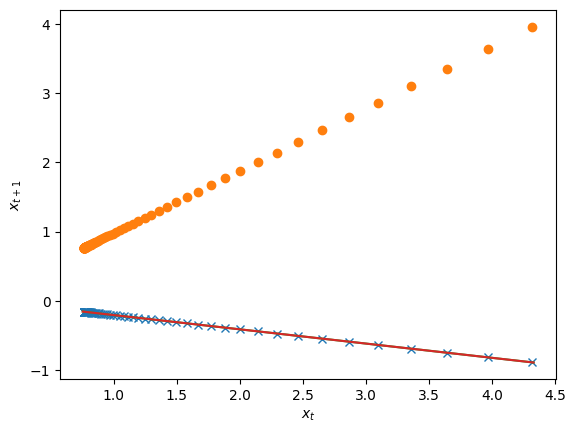

-0.1688971983591213


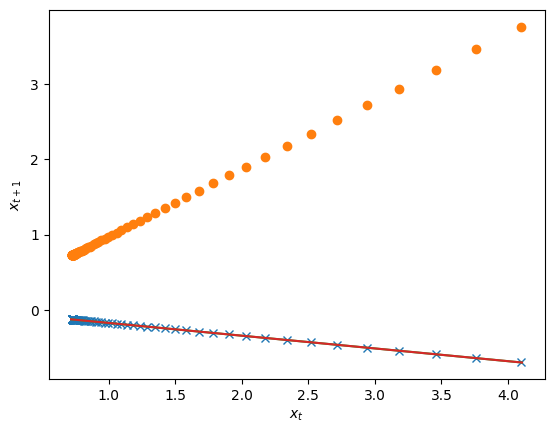

-0.13230271948384095


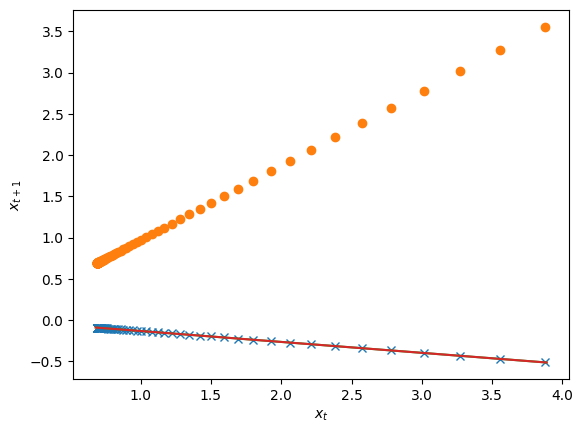

-0.09610515845798397


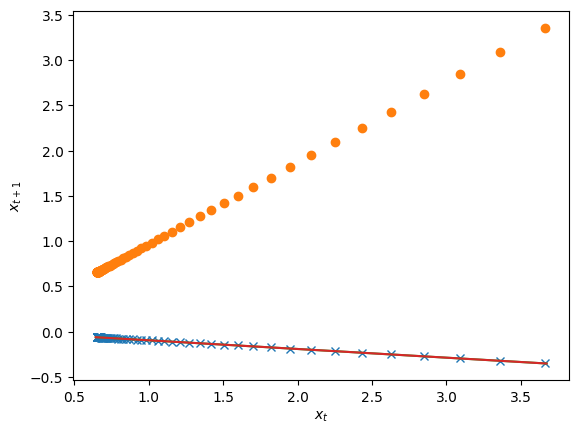

-0.06038792890909984


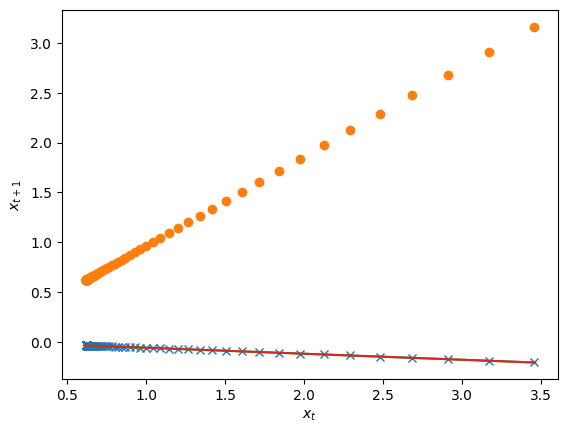

-0.025125925786350256


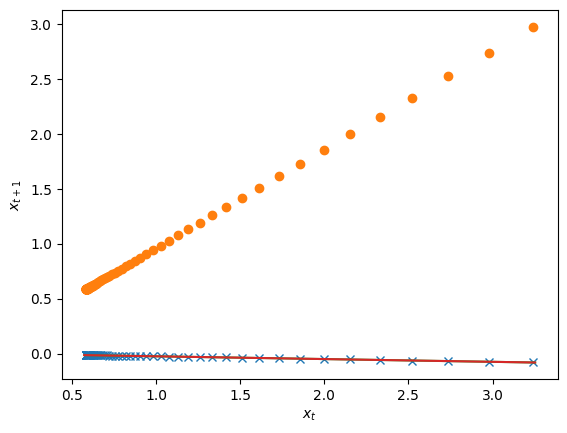

0.009744325903963694


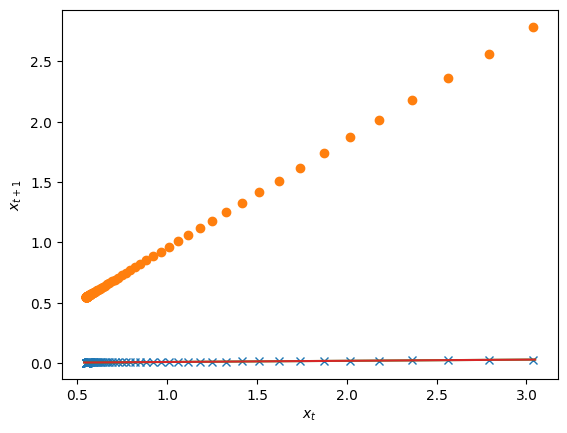

0.04414563672436245


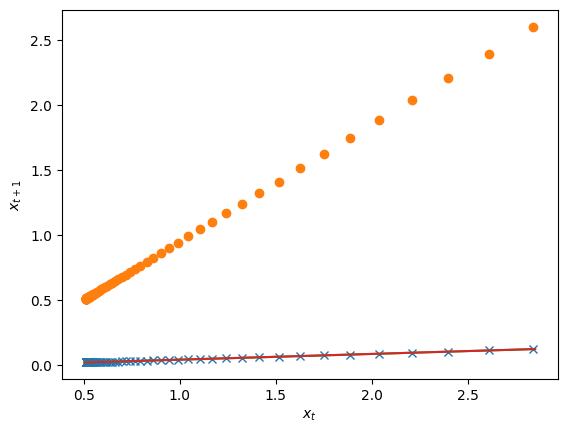

0.07802245165572225


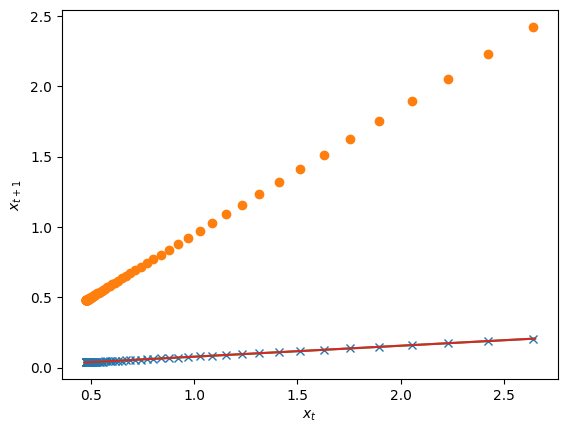

0.11137733674651479


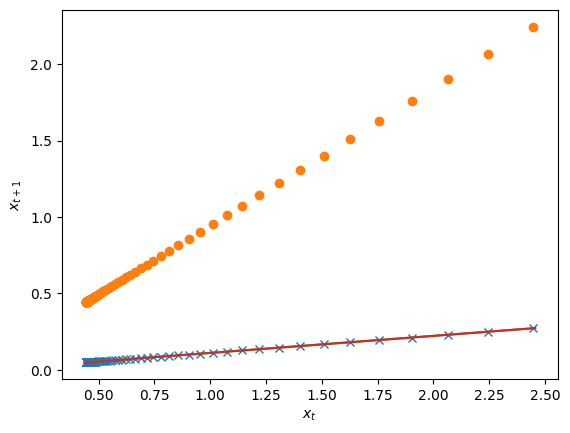

0.14428575338171487


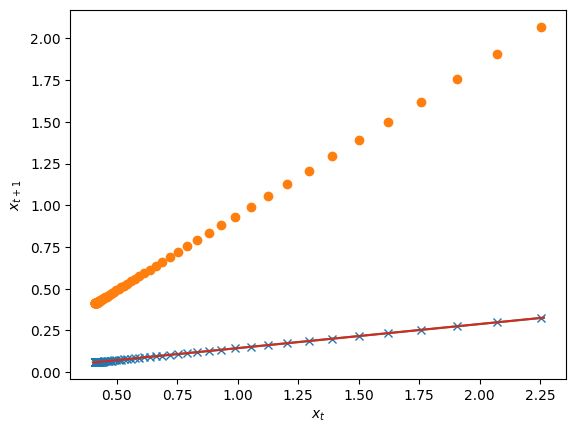

0.176760642503071


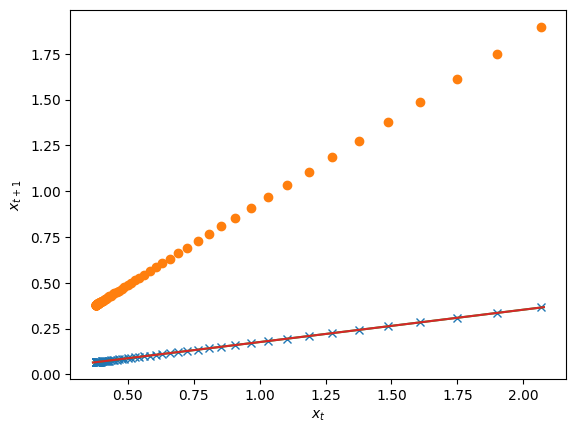

0.2088122205072978


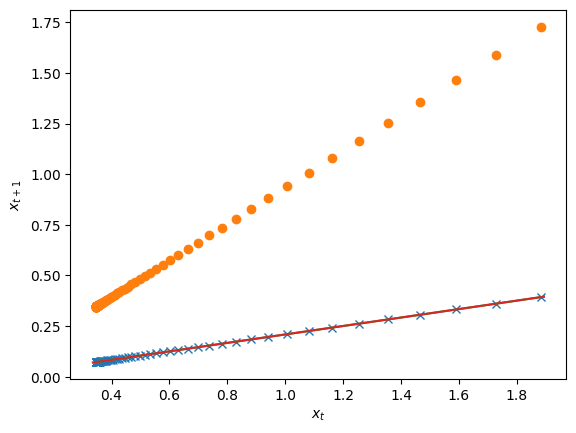

0.24047439932552278


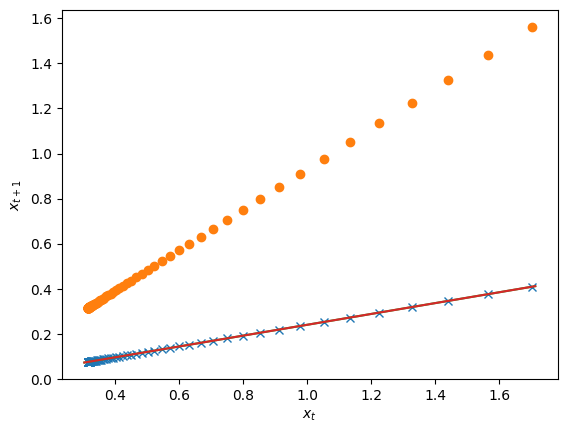

0.2717549770914914


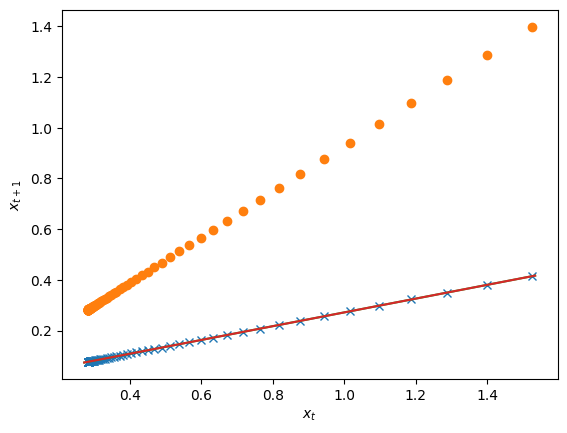

0.30265485125792746


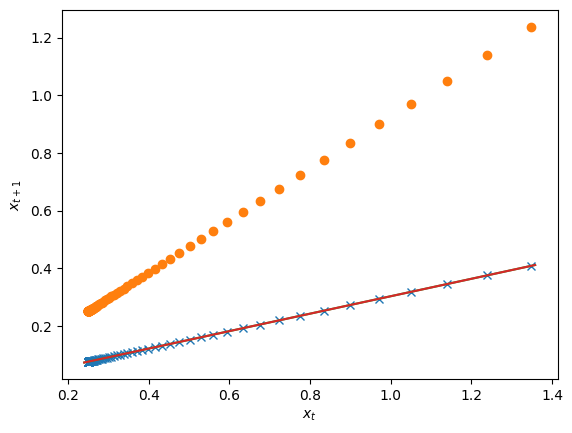

0.33322757717973045


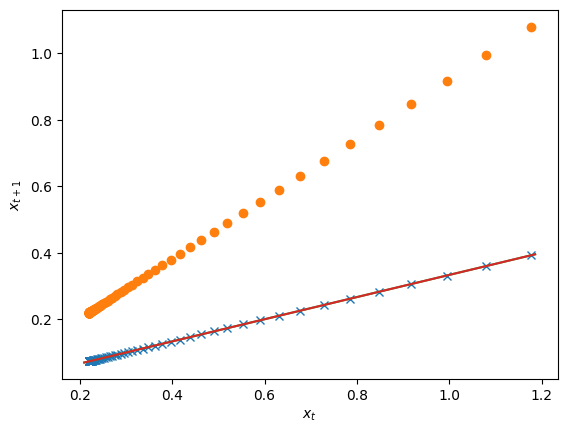

0.3634794467118301


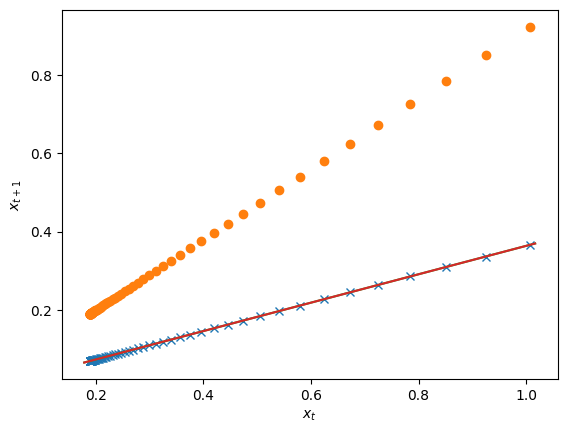

0.39342135253205773


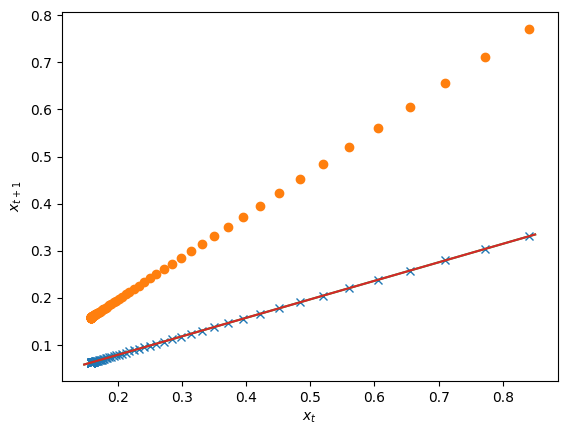

0.4230706847863902


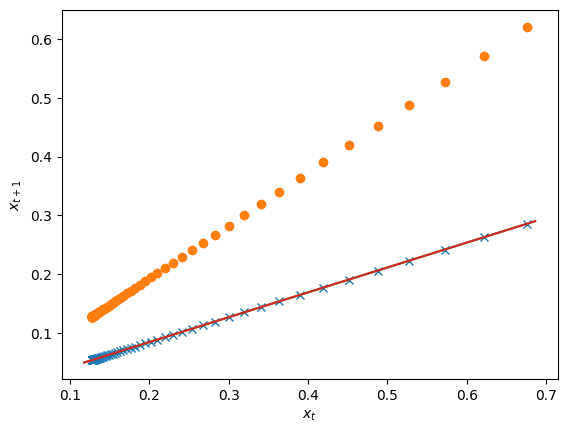

0.45244123522047874


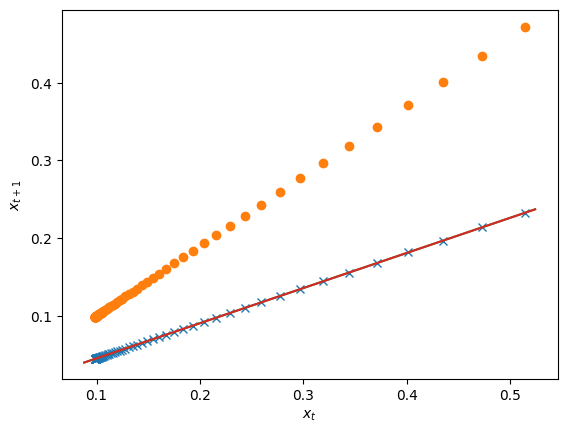

0.48155246233009374


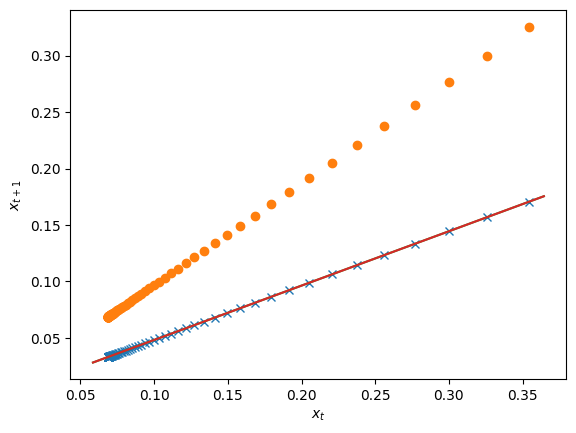

0.510423647504585


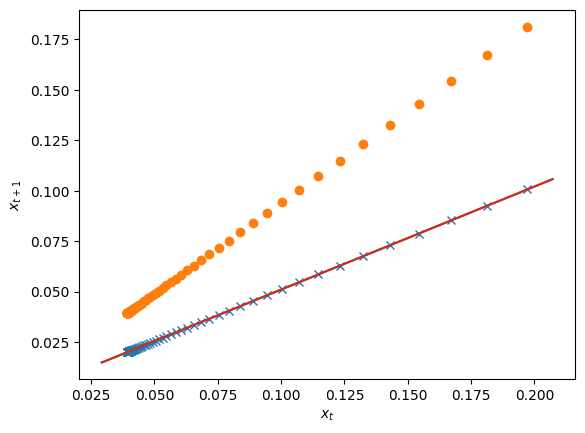

0.5390700924729688


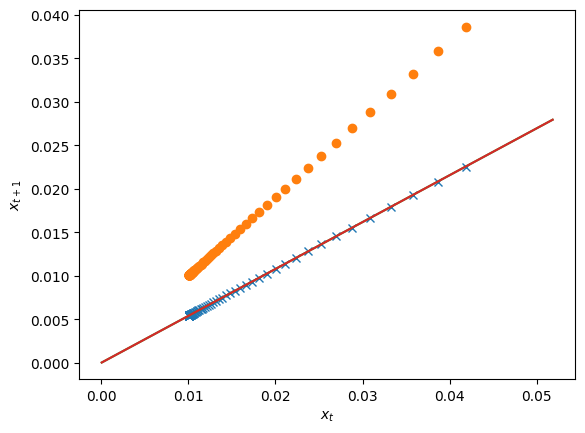

0.5675083979087022


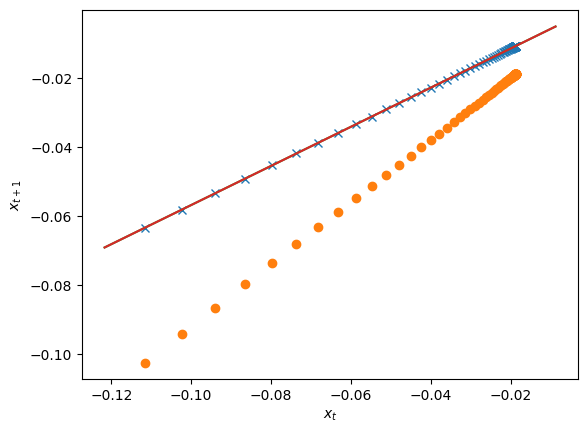

0.5957543296652128


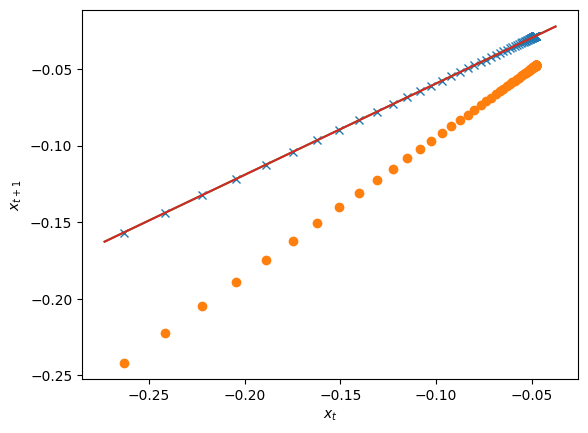

0.6238230265336177


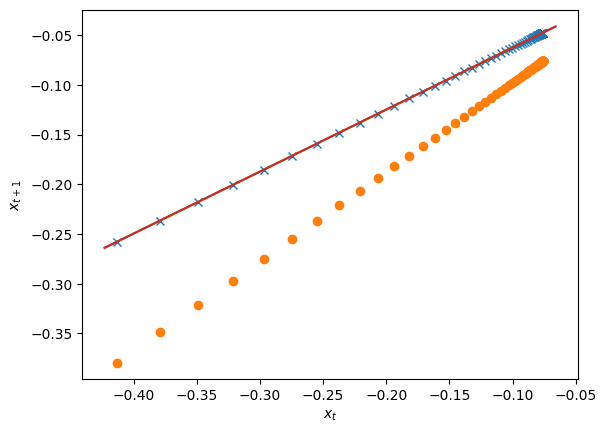

0.6517278638746836


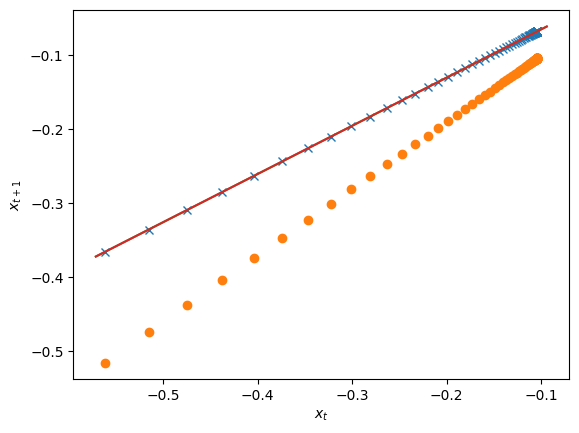

0.6794823128590007


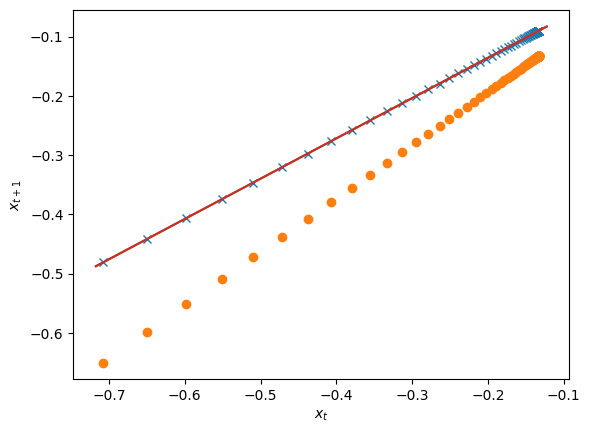

0.7070973988758189


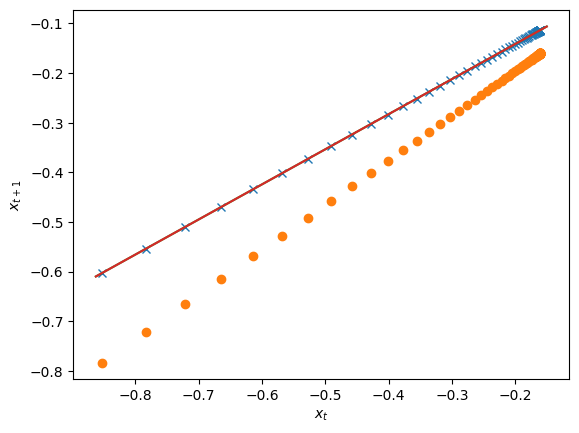

0.7345866233907774


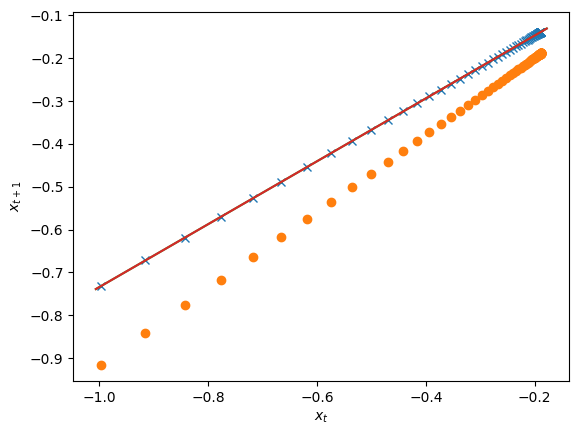

0.7619613427467011


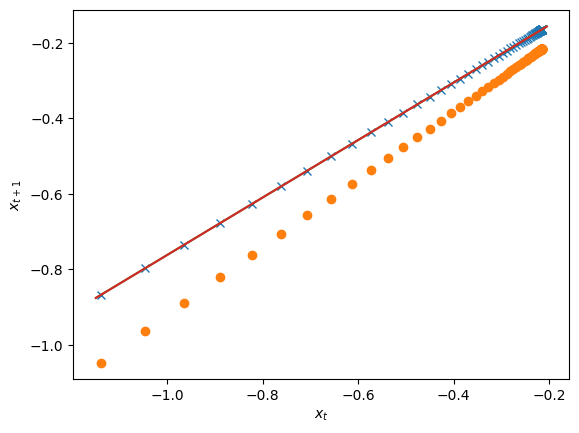

0.7892319486534829


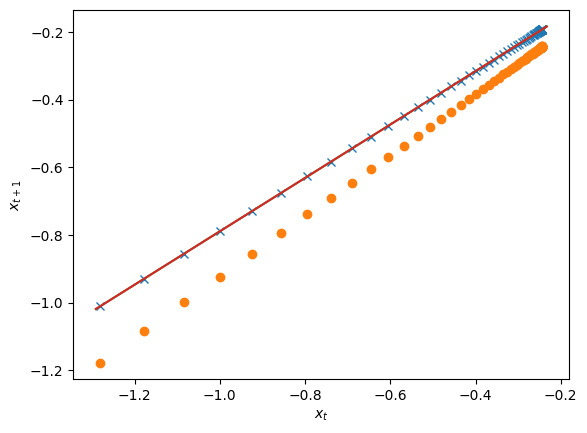

0.8164092328055076


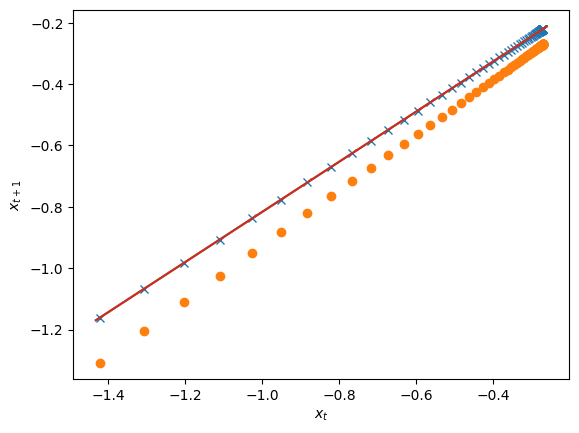

0.8435026811867119


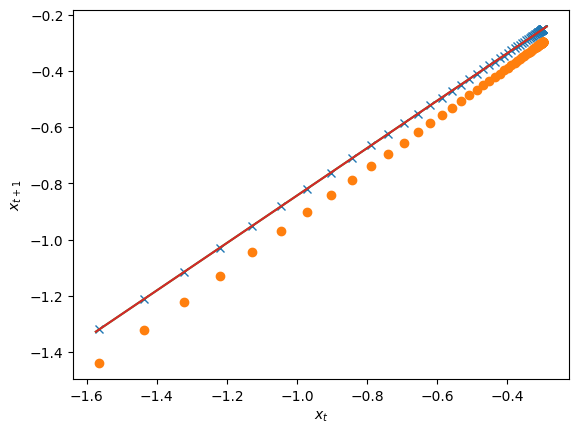

0.8705198152513365


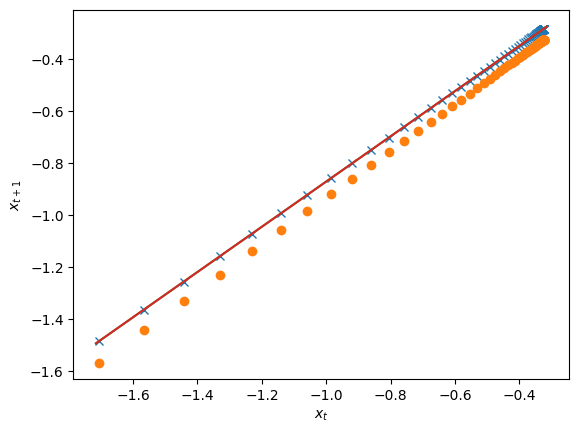

0.8974680699829368


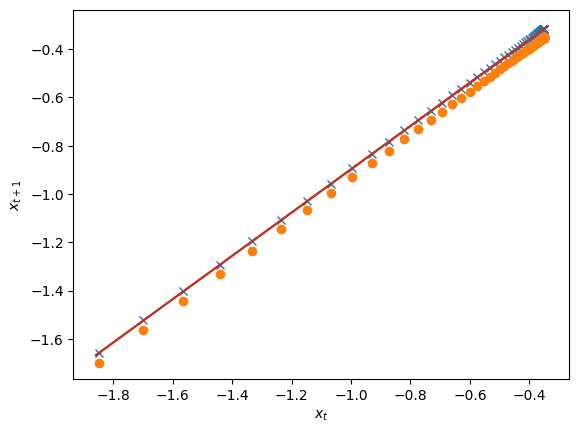

0.9243498779189692


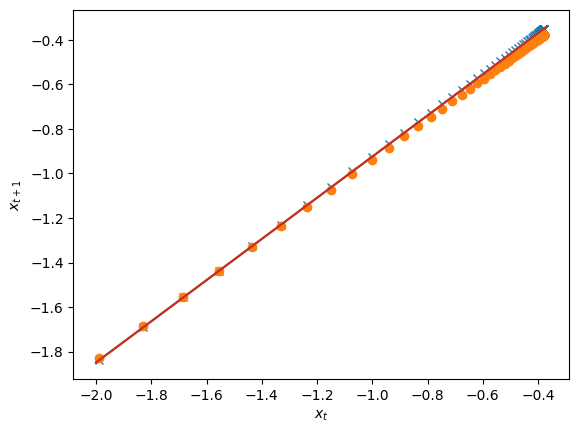

0.9511712435471238


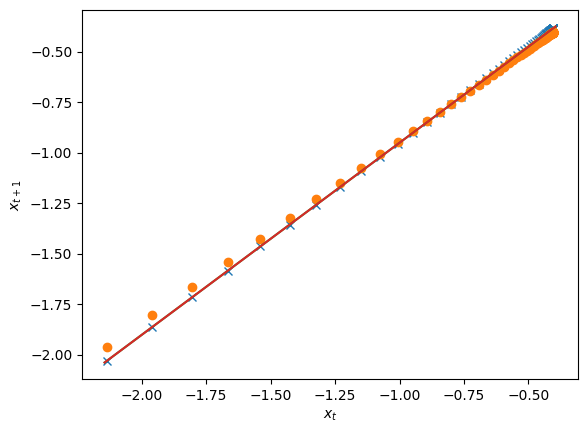

0.9779358276875934


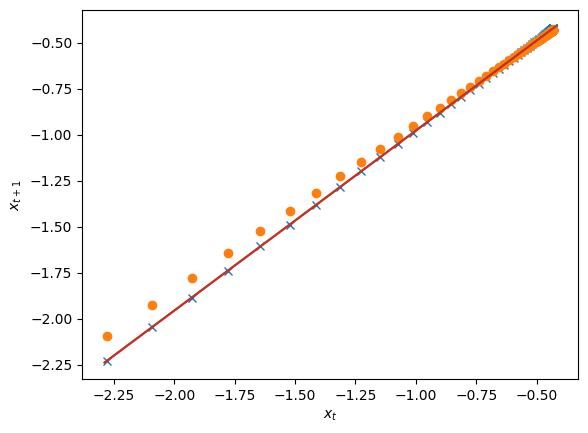

1.0046511555041804


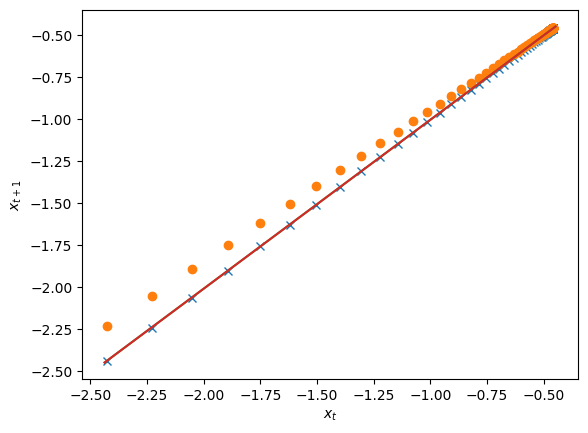

1.0313126393599963


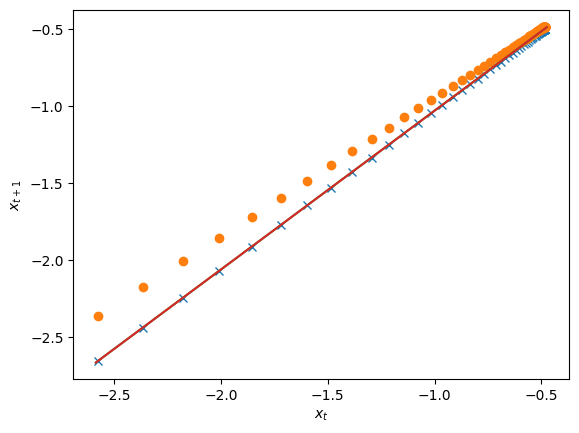

1.0579247334952533


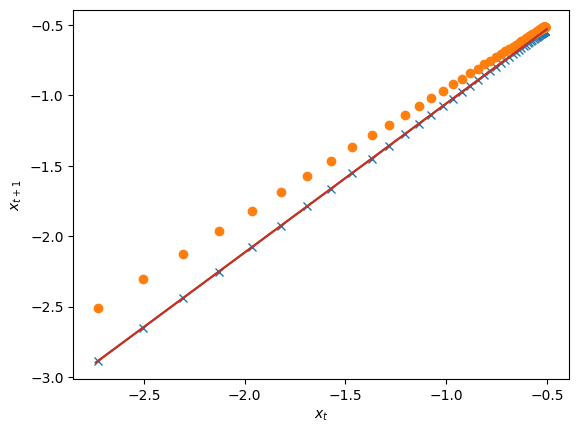

1.0844928747043359


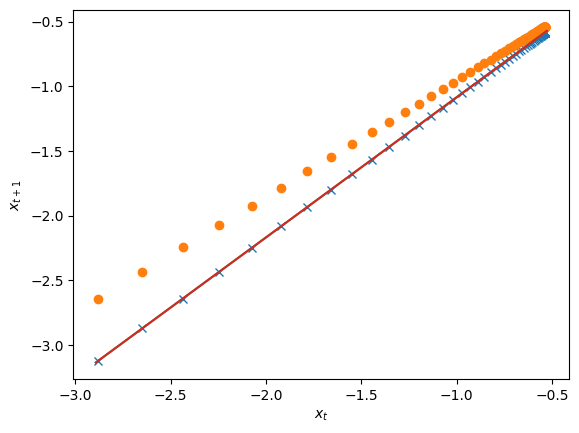

1.1110146453281162


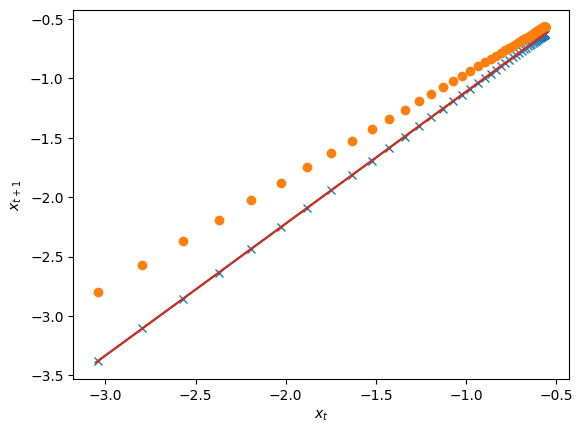

In [312]:
dataset = TOffsetDataset(trajectory)
loader = DataLoader(dataset, batch_size=4, shuffle=True)
model = TestKAE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

mse = nn.MSELoss()

EPOCHS = 50

for epoch in range(EPOCHS):
    for x_t, x_t_plus_1 in loader:

        z_t = model.encoder(x_t)
        #encoded next state
        z_t_plus_1 = model.encoder(x_t_plus_1)
        #decoded current state
        reconstructed_x_t = model.decoder(z_t)
        #linear projected encoded next state
        pz_t_plus_1 = model.linear_dynamics(z_t)
        #projected decoded next state
        reconstructed_px_t_plus_1 = model.decoder(pz_t_plus_1)

        ### RECONSTRUCTION LOSS ###
        loss_reconstruction = mse(x_t, reconstructed_x_t)

        ### PREDICTION LOSS ###
        loss_prediction = mse(reconstructed_px_t_plus_1, x_t_plus_1)

        ### LINEARITY LOSS ###
        loss_linearity = mse(pz_t_plus_1, z_t_plus_1)

        ### TOTAL LOSS ###
        loss_total = loss_reconstruction + loss_prediction + loss_linearity

        loss_total.backward()
        optimizer.step()    

    X0_all = []
    X1_predicted_all = []
    X1_all = []
    with torch.no_grad():
        for x_t, x_t_plus_1 in loader:

            z_t = model.encoder(x_t)
            #encoded next state
            z_t_plus_1 = model.encoder(x_t_plus_1)
            #decoded current state
            reconstructed_x_t = model.decoder(z_t)
            #linear projected encoded next state
            pz_t_plus_1 = model.linear_dynamics(z_t)
            #projected decoded next state
            reconstructed_px_t_plus_1 = model.decoder(pz_t_plus_1)

            X0_all.append(z_t.detach().numpy().flatten())
            X1_predicted_all.append(pz_t_plus_1.detach().numpy().flatten())
            X1_all.append(z_t_plus_1.detach().numpy().flatten())

    X0_all = np.column_stack(X0_all).flatten()
    X1_predicted_all = np.column_stack(X1_predicted_all).flatten()
    X1_all = np.column_stack(X1_all).flatten()

    visualize_pred_vs_real_dynamics(X0_all, X1_predicted_all, X1_all, model.linear_dynamics.weight.item())

0.9951477454355194


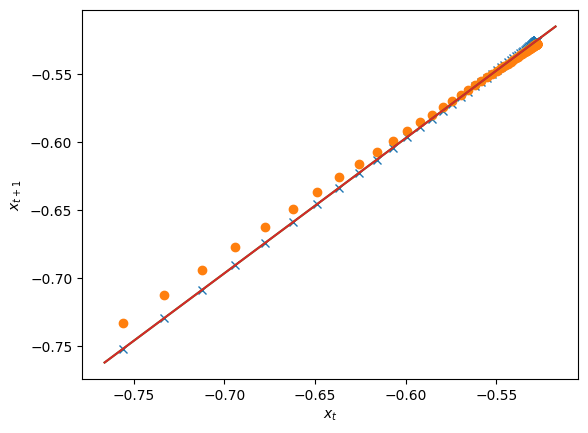

0.998452614661735


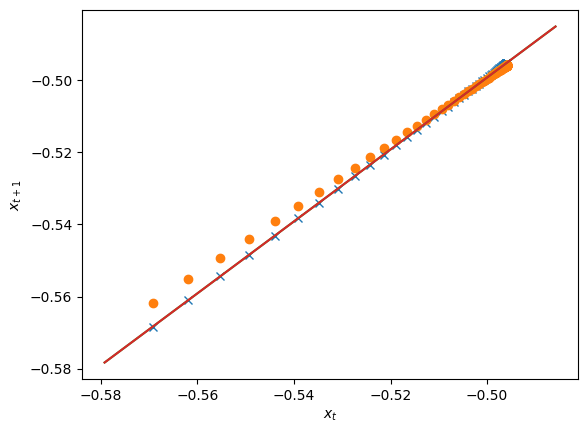

1.0020871748167932


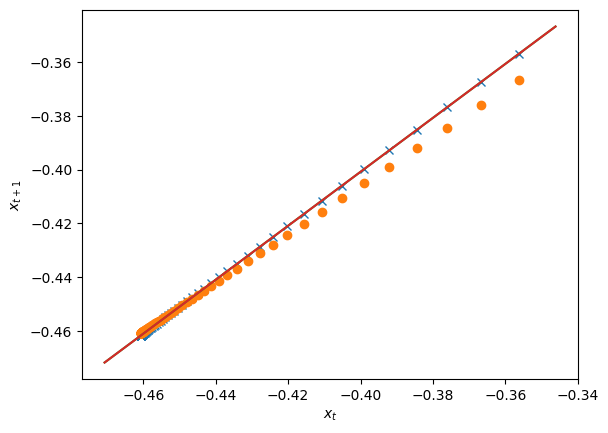

1.0048535292876828


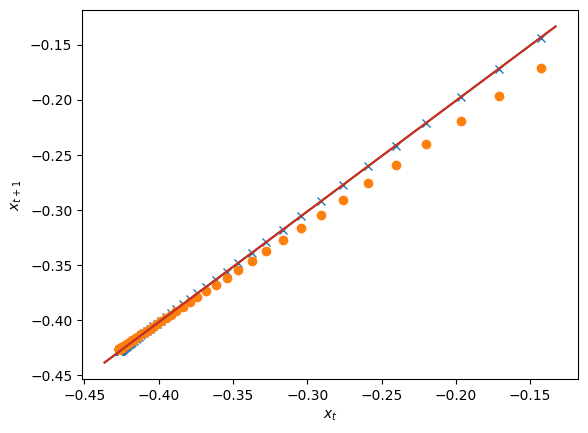

1.0053385537433444


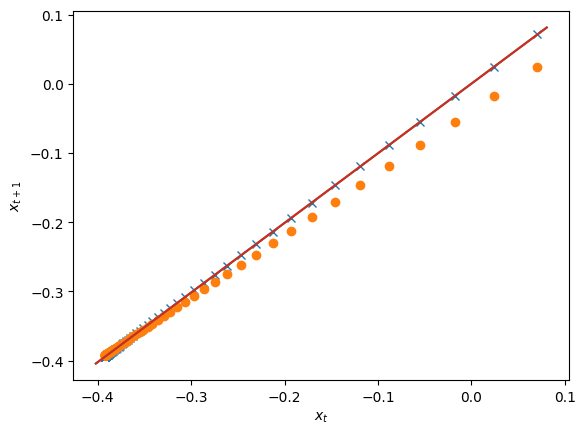

1.00130146048229


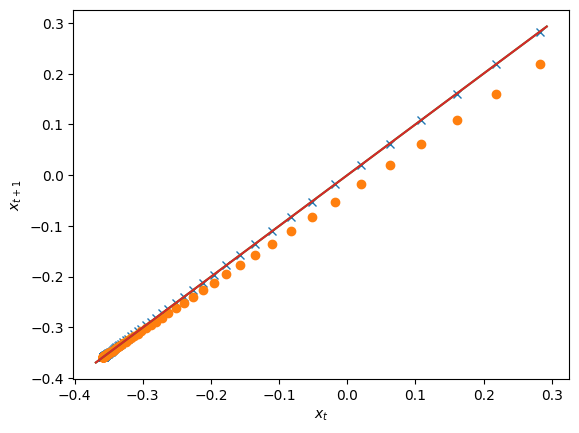

0.9902094576210498


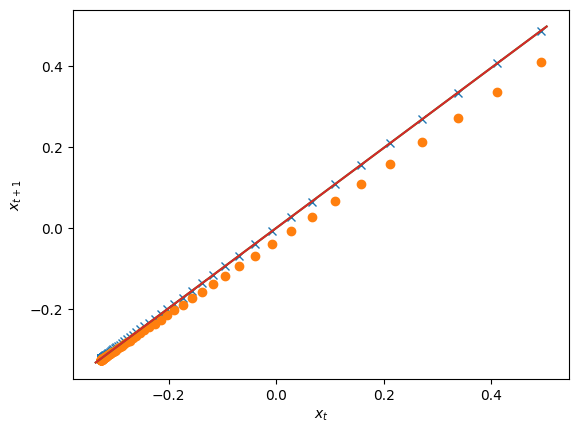

0.971789994234814


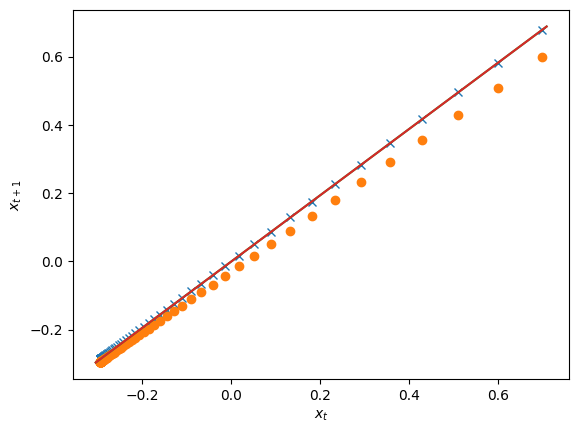

0.949311952620034


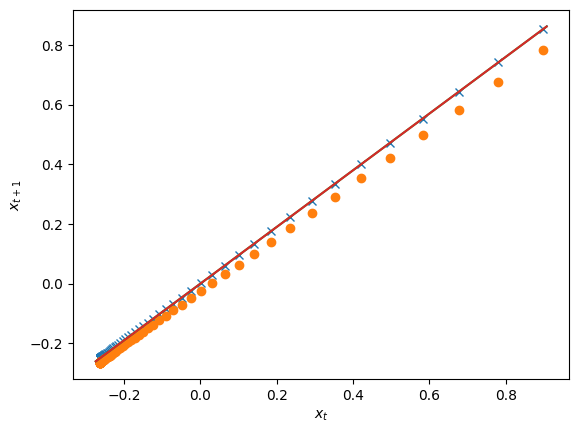

0.9280842220955244


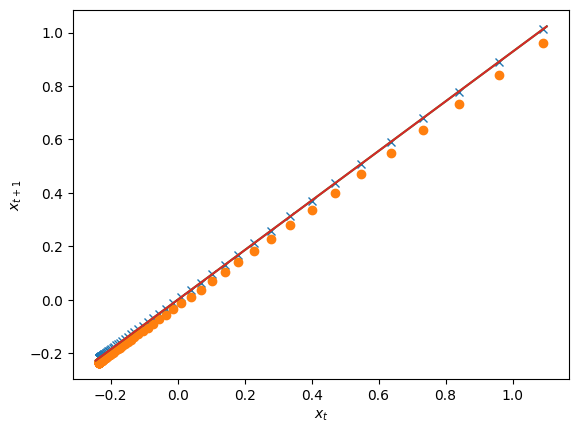

0.9120370899154755


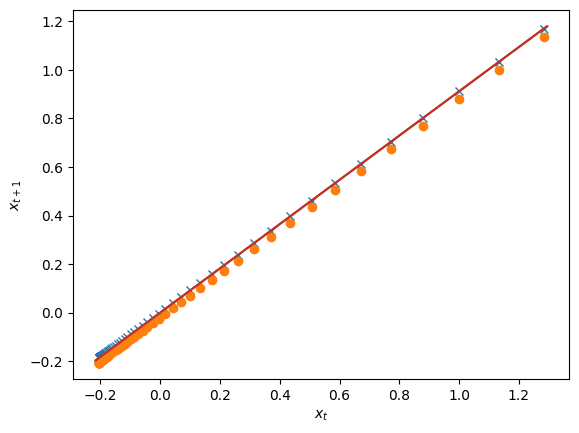

0.9019775786040313


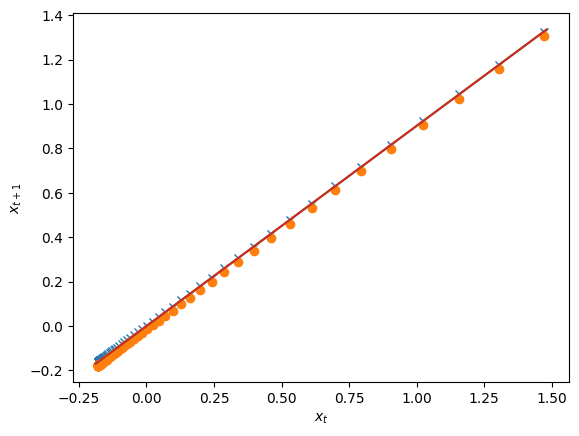

0.8967338667618039


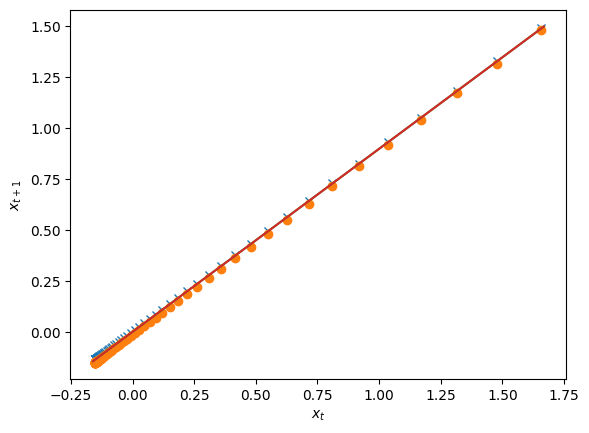

0.894695785292454


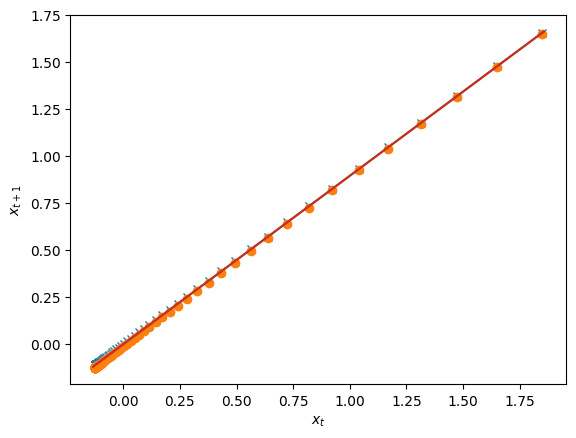

0.8945287187039785


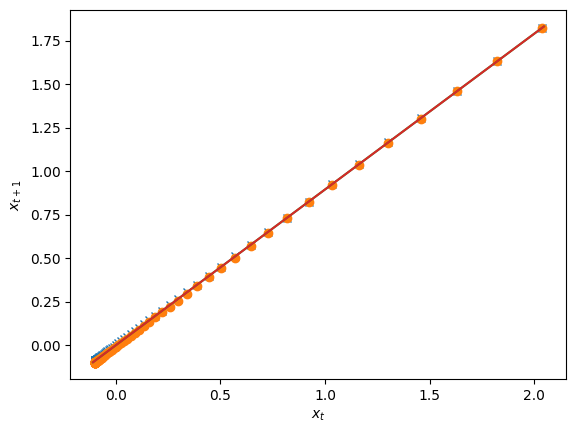

0.8952533366028295


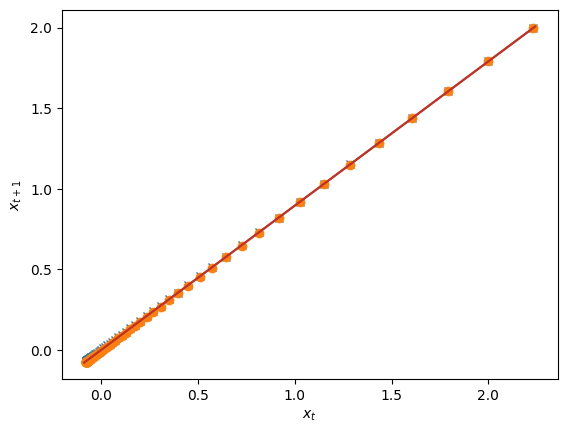

0.8962499007385366


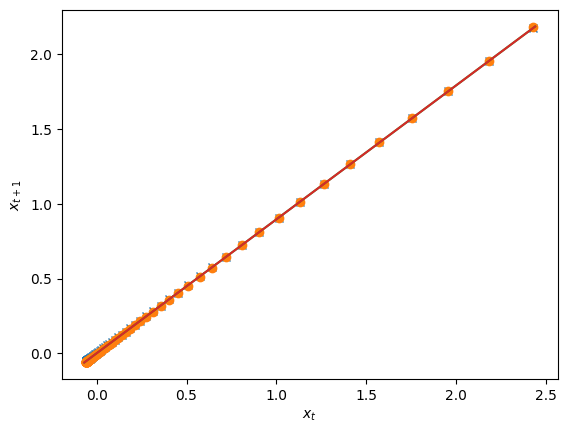

0.8971110455374693


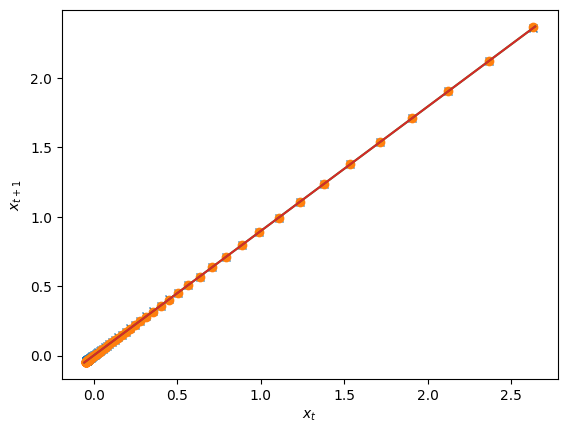

0.8975447768604206


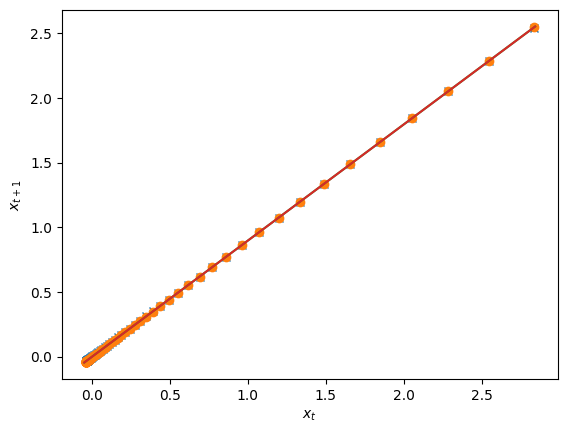

0.8974584383944707


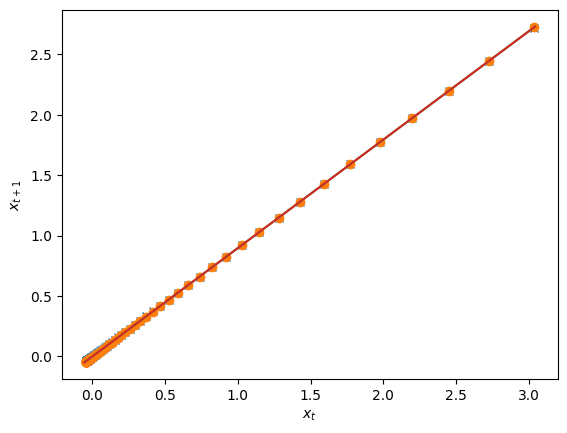

0.8967967599889214


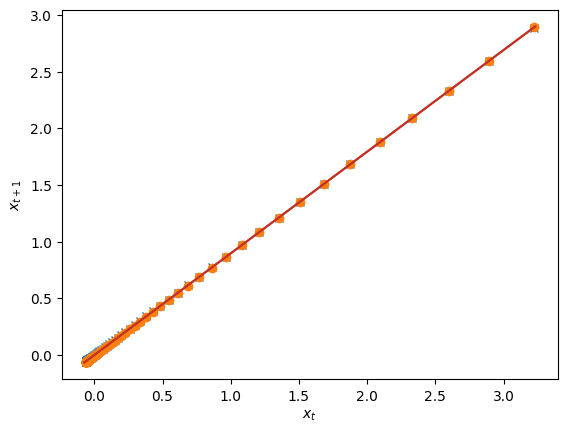

0.8957869457861811


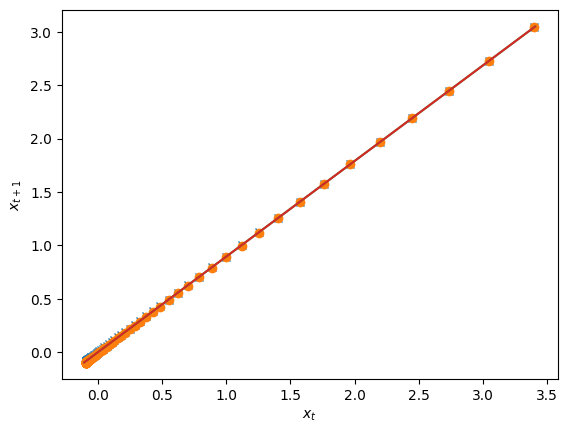

0.8948844407686513


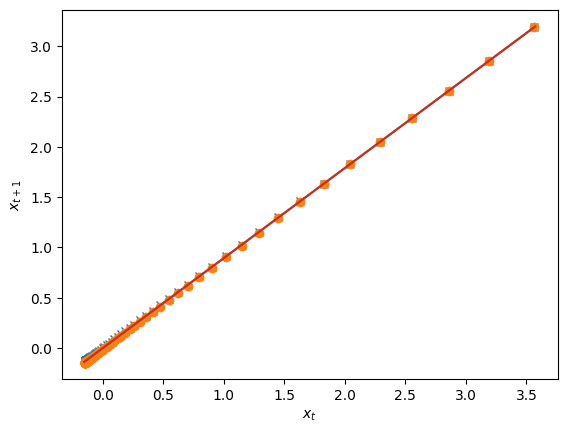

0.8944573473933654


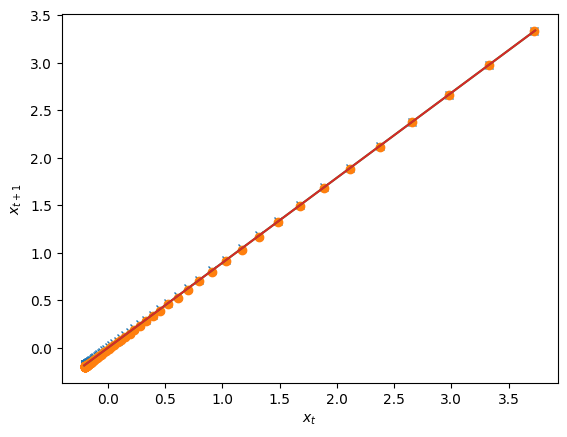

0.894646027723123


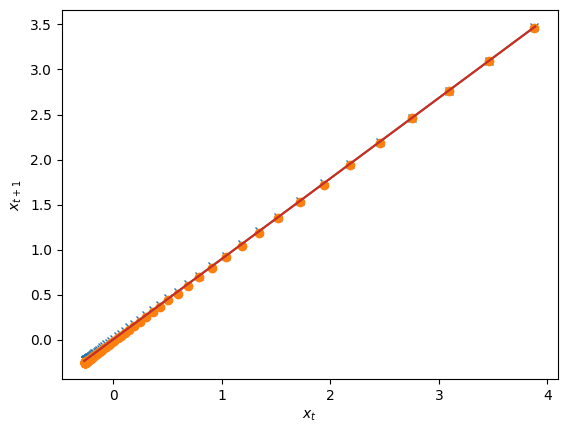

0.8954050885812325


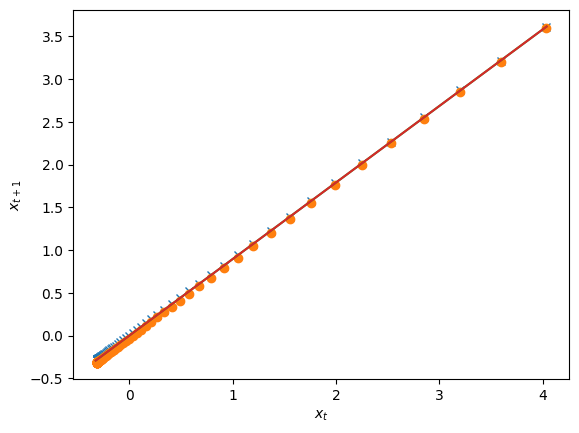

0.89654531057721


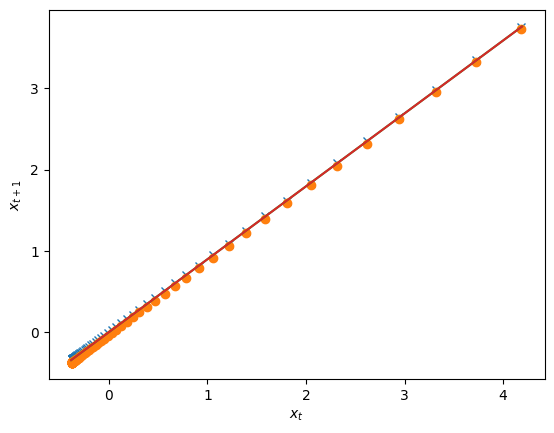

0.8978776472050797


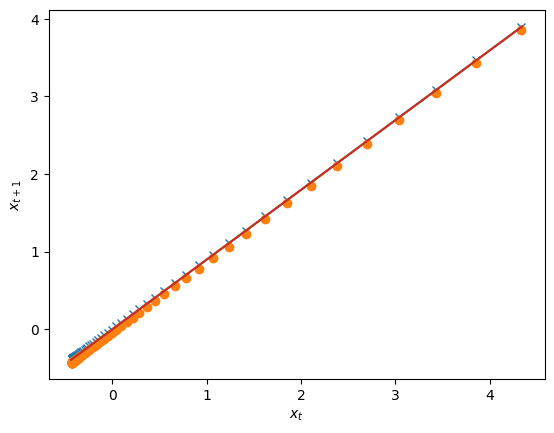

0.8992297140007485


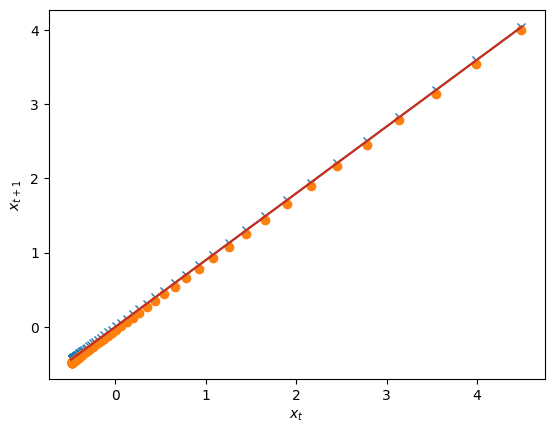

0.9004767225657807


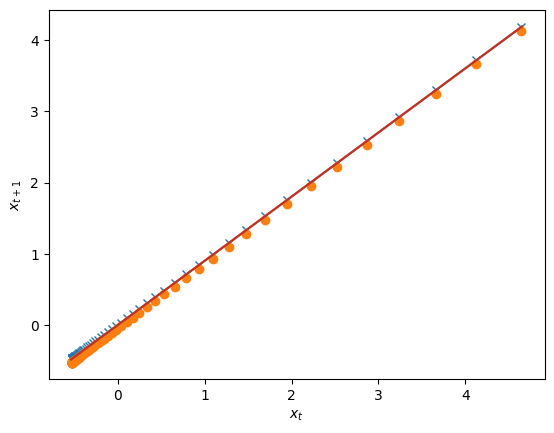

0.9015172085380521


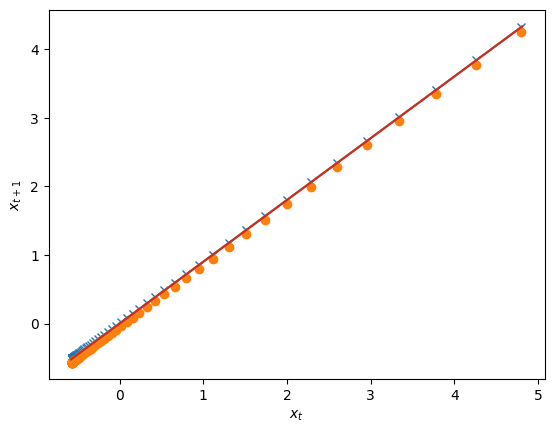

0.9022714228101828


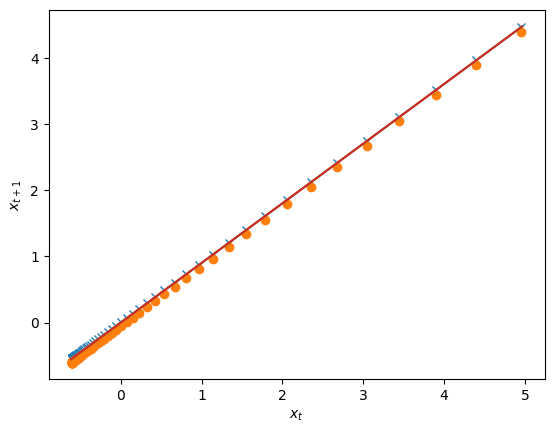

0.9026990742335892


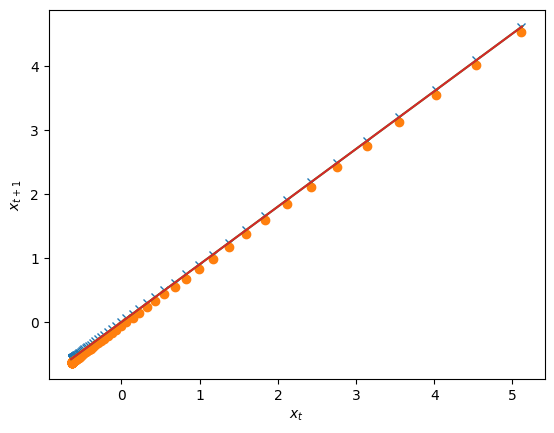

0.9027377948856141


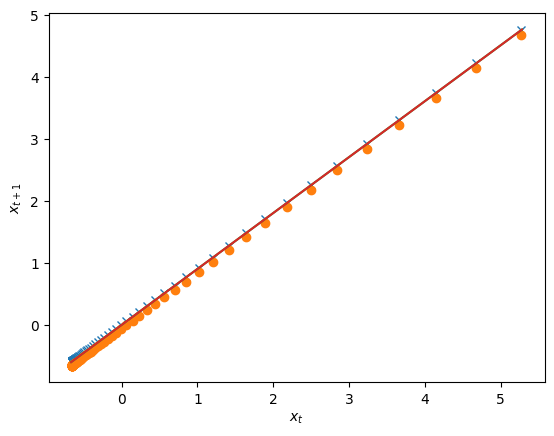

0.9023675914586191


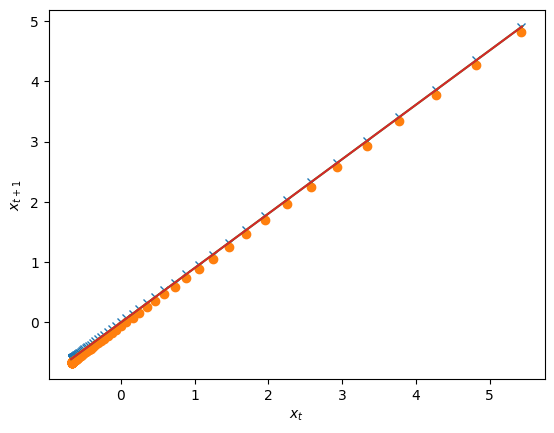

0.9015949219925501


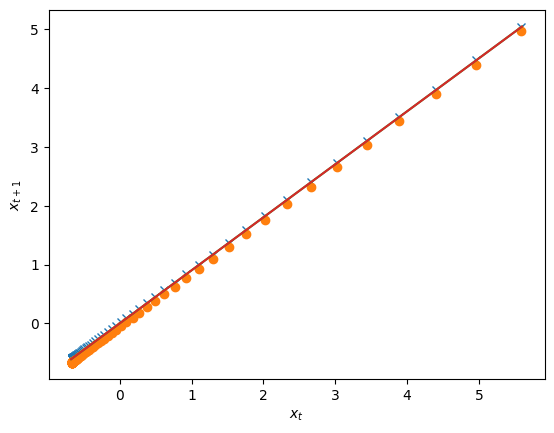

0.9004487675357448


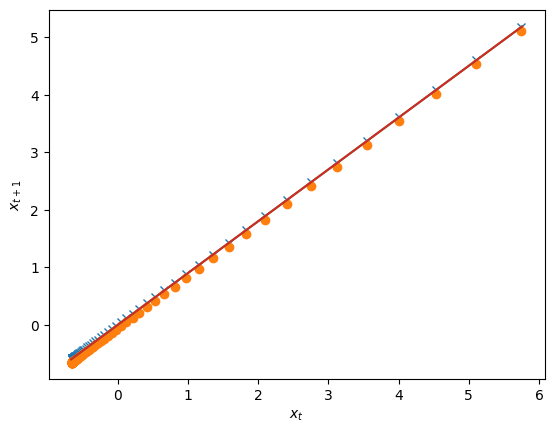

0.8990804312291207


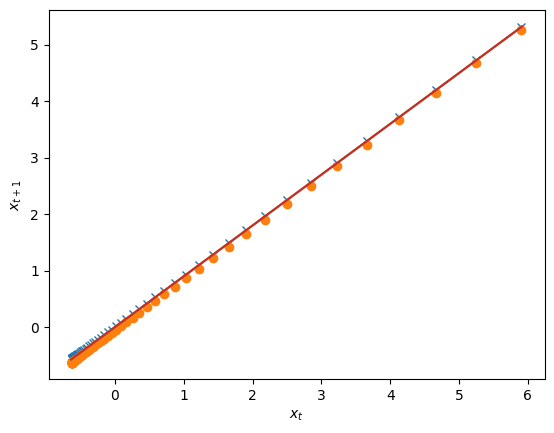

0.897659011914929


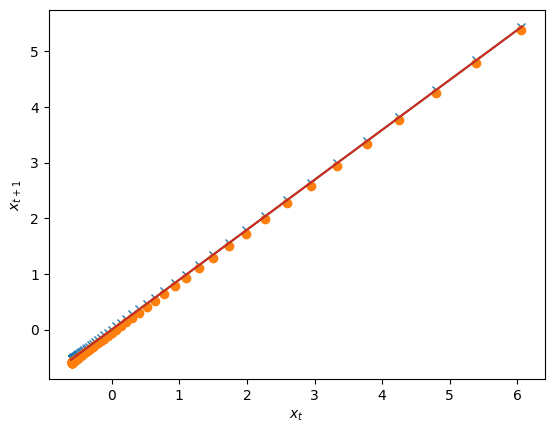

0.8964084548782022


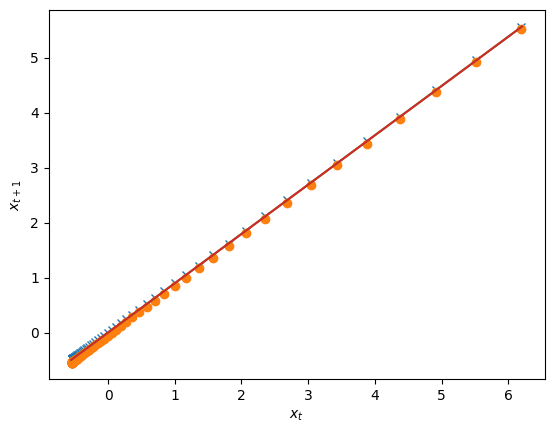

0.8954775953912621


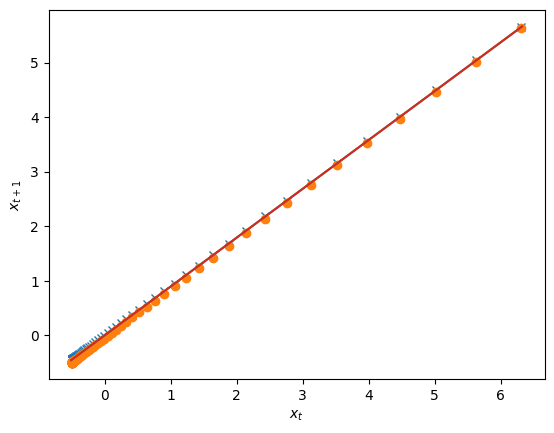

0.8948517328819573


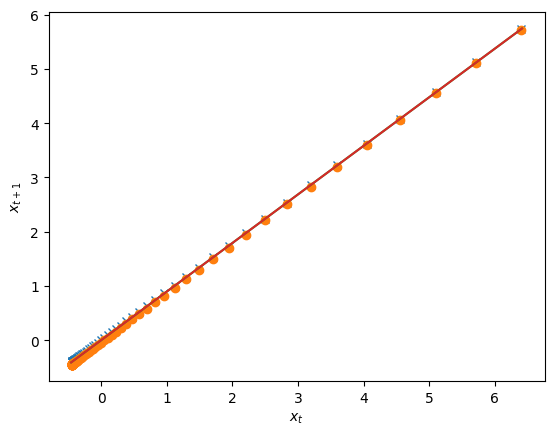

0.8945339352519245


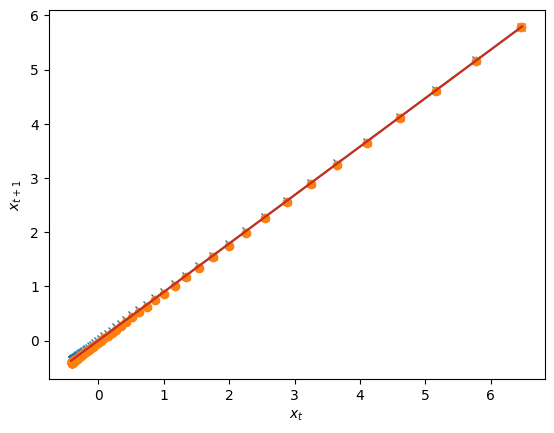

0.8944448863767104


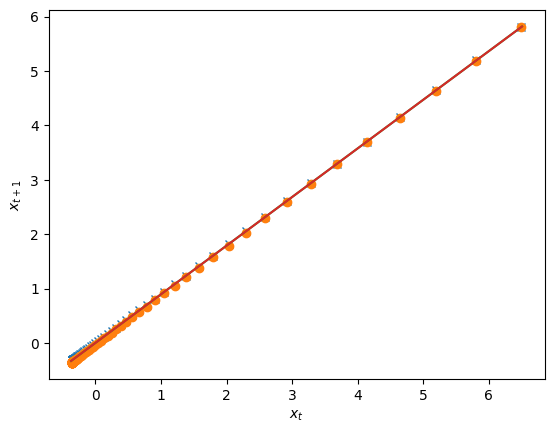

0.8945161209200693


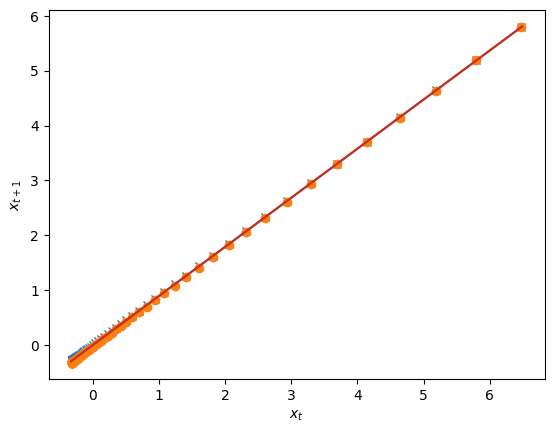

0.8946743861920942


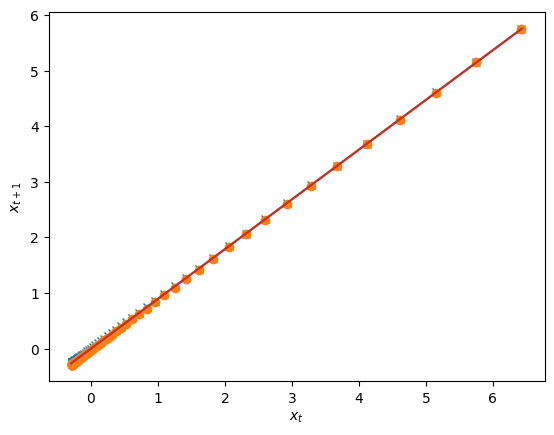

0.8948719137368392


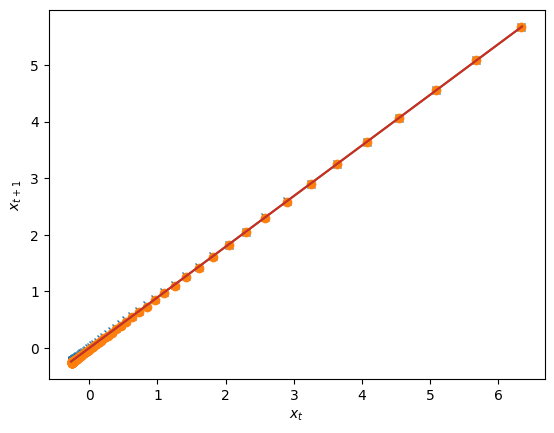

0.8950672587974191


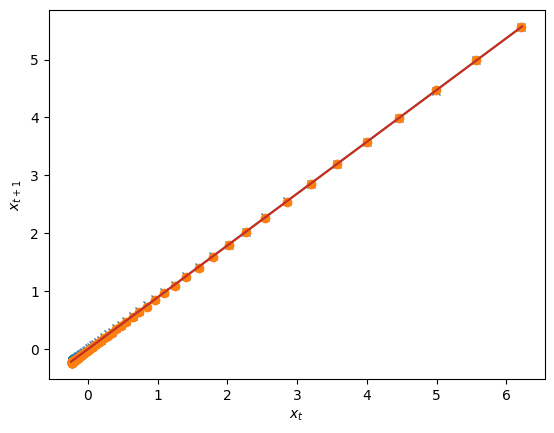

0.8952308730868324


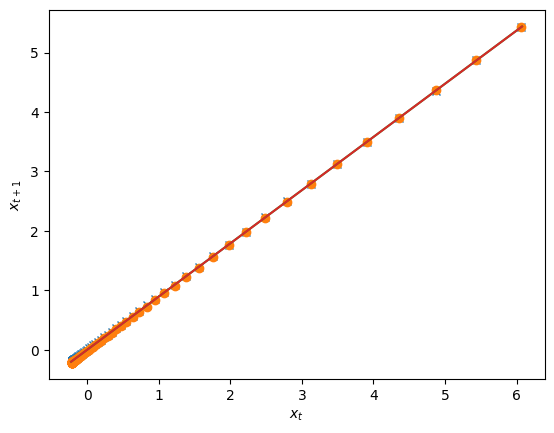

0.895355724721491


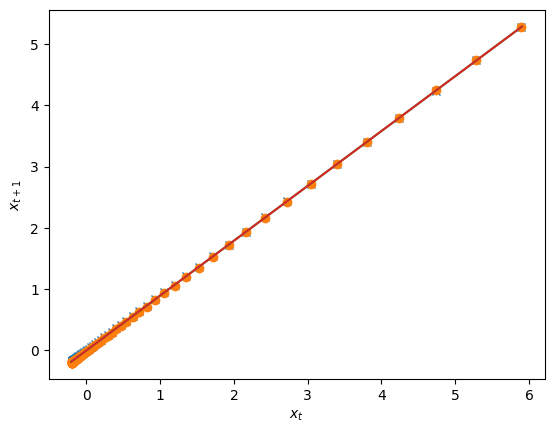

In [313]:
dataset = TOffsetDataset(trajectory)
loader = DataLoader(dataset, batch_size=4, shuffle=True)
model = ManualKAE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

mse = nn.MSELoss()

EPOCHS = 50

def calculate_linear_weights(model, loader):
    Z0_all = []
    Z1_all = []
    with torch.no_grad():
        for x_t, x_t_plus_1 in loader:
            z_t = model.encoder(x_t)
            #encoded next state
            z_t_plus_1 = model.encoder(x_t_plus_1)
            Z0_all.append(z_t.detach().numpy().flatten())
            Z1_all.append(z_t_plus_1.detach().numpy().flatten())
    Z0_all = np.column_stack(Z0_all).flatten()
    Z1_all = np.column_stack(Z1_all).flatten()
    K = np.expand_dims(Z1_all, 0) @ np.linalg.pinv(np.expand_dims(Z0_all,0))
    
    linear_weights = torch.tensor(K)
    return linear_weights


for epoch in range(EPOCHS):

    linear_weights = calculate_linear_weights(model, loader)

    for x_t, x_t_plus_1 in loader:

        z_t = model.encoder(x_t)
        #encoded next state
        z_t_plus_1 = model.encoder(x_t_plus_1)
        #decoded current state
        reconstructed_x_t = model.decoder(z_t)
        #linear projected encoded next state
        pz_t_plus_1 = nn.functional.linear(z_t, linear_weights)
        #projected decoded next state
        reconstructed_px_t_plus_1 = model.decoder(pz_t_plus_1)

        ### RECONSTRUCTION LOSS ###
        loss_reconstruction = mse(x_t, reconstructed_x_t)

        ### PREDICTION LOSS ###
        loss_prediction = mse(reconstructed_px_t_plus_1, x_t_plus_1)

        ### LINEARITY LOSS ###
        loss_linearity = mse(pz_t_plus_1, z_t_plus_1)

        ### TOTAL LOSS ###
        loss_total = loss_reconstruction + loss_prediction + loss_linearity

        loss_total.backward()
        optimizer.step()    


    linear_weights = calculate_linear_weights(model, loader)

    X0_all = []
    X1_predicted_all = []
    X1_all = []
    with torch.no_grad():
        for x_t, x_t_plus_1 in loader:

            z_t = model.encoder(x_t)
            #encoded next state
            z_t_plus_1 = model.encoder(x_t_plus_1)
            #decoded current state
            reconstructed_x_t = model.decoder(z_t)
            #linear projected encoded next state
            pz_t_plus_1 = nn.functional.linear(z_t, linear_weights)
            #projected decoded next state
            reconstructed_px_t_plus_1 = model.decoder(pz_t_plus_1)

            X0_all.append(z_t.detach().numpy().flatten())
            X1_predicted_all.append(pz_t_plus_1.detach().numpy().flatten())
            X1_all.append(z_t_plus_1.detach().numpy().flatten())

    X0_all = np.column_stack(X0_all).flatten()
    X1_predicted_all = np.column_stack(X1_predicted_all).flatten()
    X1_all = np.column_stack(X1_all).flatten()

    visualize_pred_vs_real_dynamics(X0_all, X1_predicted_all, X1_all, linear_weights.item())